In [1]:
# %pip install --upgrade pip
%pip install gmsh
%pip install meshio --user

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python39\python.exe -m pip install --upgrade pip' command.


In [1]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt


In [2]:
gmsh.initialize()

dx = 0.05
points = [
  gmsh.model.geo.addPoint(0, 0, 0, dx),
  gmsh.model.geo.addPoint(1, 0, 0, dx),
  gmsh.model.geo.addPoint(1, 1, 0, dx),
  gmsh.model.geo.addPoint(0, 1, 0, dx),
  gmsh.model.geo.addPoint(0.5, 0.5, 0, dx),
  gmsh.model.geo.addPoint(0.75, 0.5, 0, dx),
  gmsh.model.geo.addPoint(0.25, 0.5, 0, dx),
]
lines = [
  gmsh.model.geo.add_line(points[0], points[1]),
  gmsh.model.geo.add_line(points[1], points[2]),
  gmsh.model.geo.add_line(points[2], points[3]),
  gmsh.model.geo.add_line(points[3], points[0]),
]

import numpy as np
arcs = [
  gmsh.model.geo.addCircleArc(points[5], points[4], points[6]),
  gmsh.model.geo.addCircleArc(points[6], points[4], points[5]),
]

loops = [
  gmsh.model.geo.add_curve_loop(lines),
  gmsh.model.geo.add_curve_loop(arcs),
]

surfaces = [gmsh.model.geo.add_plane_surface([loops[0], loops[1]])]

# Physical groups
surfaces_physical = [gmsh.model.addPhysicalGroup(2, surfaces, name="surface")]
lines_physical = [gmsh.model.addPhysicalGroup(1, lines, name=f"box")]
arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs, name=f"circle")]

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate()
gmsh.write("test_mesh.msh")

import sys
if 'close' not in sys.argv:
    gmsh.fltk.run()

gmsh.finalize()

In [3]:
''' Read mesh and process '''
import meshio
mesh = meshio.read("test_mesh.msh")
mesh

<meshio mesh object>
  Number of points: 451
  Number of cells:
    line: 20
    line: 20
    line: 20
    line: 20
    line: 16
    line: 16
    triangle: 790
  Cell sets: box, circle, surface, gmsh:bounding_entities
  Point data: gmsh:dim_tags
  Cell data: gmsh:physical, gmsh:geometrical
  Field data: box, circle, surface

In [4]:
n_nodes = mesh.points.shape[0]
n_cells = mesh.cells[2].data.shape[0]
n_nodes, n_cells

(451, 20)

In [5]:
mesh.points.shape, mesh.cells[2].data.shape

((451, 3), (20, 2))

In [6]:
import numpy as np
# # Map form cell to node index (ncells, 3) (JANK)
# cell2nodes = np.array([mesh.cells[-1].data])[0]
# # Point position by cell (ncells, 3, ndim)
# points_by_cell = mesh.points[cell2nodes][:,:,0:2]

(790, 3, 3)

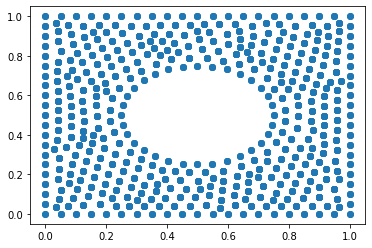

In [ ]:
# List of arrays containing triangles [node_idx_i, node_idx_j, node_idx_k]
tri_nodes= [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets["surface"])]
tri_nodes_flat = np.concatenate([part for part in tri_nodes if part.size > 0])
tri_points = mesh.points[tri_nodes_flat]

plt.scatter(tri_points[...,0].ravel(), tri_points[...,1].ravel())
tri_points.shape

(80, 2, 3)

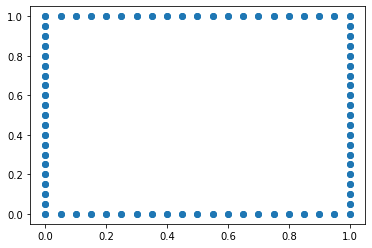

In [8]:
# List of arrays containing edges [node_idx_i, node_idx_j]
box_edges = [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets["box"])]
# Array of edges with shape (ne, 2) belonging to box boundary
box_edges_flat = np.concatenate([part for part in box_edges if part.size > 0])
# Reverse orientation for outside border
box_edges_flat = np.flip(box_edges_flat, axis=1)

# List of coordinates belonging to each edge (n_edges, 2 (vertices on edge), 3 (dimension))
box_points = mesh.points[box_edges_flat]

plt.scatter(box_points[...,0].ravel(), box_points[...,1].ravel())
box_points.shape

(32, 2, 3)

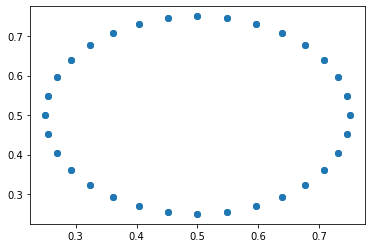

In [9]:
# List of arrays containing edges [node_idx_i, node_idx_j]
circ_edges = [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets["circle"])]
# Array of edges with shape (ne, 2) belonging to box boundary
circ_edges_flat = np.concatenate([part for part in circ_edges if part.size > 0])

# List of coordinates belonging to each edge (n_edges, 2 (vertices on edge), 3 (dimension))
circ_points = mesh.points[circ_edges_flat]

plt.scatter(circ_points[...,0].ravel(), circ_points[...,1].ravel())
circ_points.shape

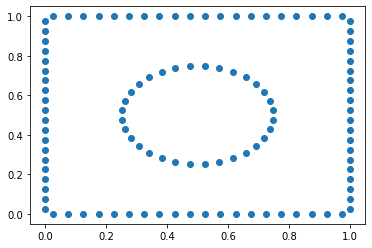

In [10]:
# Centroids by cell (ncells)
tri_centroids = tri_points.mean(axis=1, keepdims=False)

bdry_points = np.concatenate([circ_points, box_points], axis=0)

# Boundary edge centers
n_circ_elts = circ_points.shape[0]
n_box_elts = box_points.shape[0]
bdry_edge_centers = np.concatenate([circ_points.mean(axis=1, keepdims=False),
                     box_points.mean(axis=1, keepdims=False)], axis=0)
plt.scatter(bdry_edge_centers[:,0], bdry_edge_centers[:,1])


In [11]:
''' Compute tri-element areas '''
tri_areas = 0.5 * np.abs(np.cross(tri_points[:,2,:] - tri_points[:,0,:],
         tri_points[:,1,:] - tri_points[:,0,:])[:,-1])
tri_areas.sum()

0.8049096779838718

In [29]:
def G(r):
  ''' Laplace fundamental solution '''
  return -1 / (4.0 * np.pi) * np.log(np.einsum("...i, ...i -> ...", r, r))

def dGdn(r, nhat):
  ''' d/dn of Laplace fundamental solution '''
  rnorm = np.linalg.norm(r,axis=-1)
  drdn = np.einsum("...i, ...i -> ...", -nhat, r/rnorm)
  return -1 / (2.0 * np.pi * rnorm) * drdn

def rotate_vec(v):
  ''' Rotate vector counterclockwise 90 degrees along last axis '''
  w = v.copy()
  w[...,[1,0]] = w[...,[0,1]]
  w[...,0] *= -1
  return w

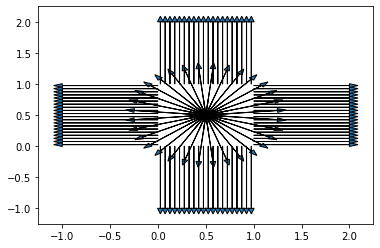

In [202]:
# Node counting
n_cells = tri_centroids.shape[0]
n_bdry_node = bdry_edge_centers.shape[0]
N = n_cells + n_bdry_node

K = np.zeros((N, n_bdry_node)) # Single-layer potential coefficient matrix (K @ du/dn)
C = np.zeros((N, n_bdry_node)) # Double-layer potential coefficient matrix (dK/dn @ u)
M = np.zeros((N, n_cells))       # Volume integral (dK/dt @ u)

# Global x points
x_nodes = np.concatenate((bdry_edge_centers[:,0:2], tri_centroids[:,0:2],), axis=0)

_plot_normal_vecs = True
_use_nodal_sing_int_1D = False
_use_nodal_sing_int_2D = False

# Compute boundary integrals
for j in range(n_bdry_node):
  # Extract information about the boundary element
  edge = bdry_points[j,:,0:2]   # (2, ndim=2)
  x = bdry_edge_centers[j,0:2]  # (2,)

  # Compute dg (dgamma), dx = |dg|, dn
  dg = edge[1] - edge[0]        # (3,)
  dx = np.linalg.norm(dg)
  dn = rotate_vec(dg)           # (3,)
  dn /= np.linalg.norm(dn)

  for i, x_target in enumerate(x_nodes):
    # Compute distance vector
    r = x_target - x # (2,)
    if np.isclose(np.linalg.norm(r), 0.0):
      
      if _use_nodal_sing_int_1D:
        # Use two nodes around singularity instead
        xn0 = edge[0] + (1.0/3.0) * dg
        xn1 = edge[0] + (2.0/3.0) * dg
        K[i,j] += (0.5 * dx * G(xn0 - x)
              + 0.5 * dx * G(xn1 - x))
      else:
        # Singular part treatment: exact integration around pole
        r_eff = (dx/2)
        K[i,j] += 2 * (-1 / (2.0 * np.pi)) * (r_eff * np.log(r_eff) - r_eff)
      
      # Should be zeros
      # B[i,j] += (0.5 * dx * dGdn(xn0 - x, dn)
            #  + 0.5 * dx * dGdn(xn1 - x, dn))
    else:
      K[i,j] += G(r) * dx # @ dudn
      C[i,j] += dGdn(r, dn) * dx # @ u

  if _plot_normal_vecs:
    plt.arrow(x[0], x[1], dn[0], dn[1], head_width=0.06)

# Compute domain integrals
for j in range(n_cells):
  # Extract information about the boundary element
  x_center = tri_centroids[j,0:2]   # (2, ndim=2)
  x_vertices = tri_points[j,:,0:2]
  tri_area = tri_areas[j]

  for i, x_target in enumerate(x_nodes):
    # Compute distance vector
    r = x_target - x_center # (2,)
    if np.isclose(np.linalg.norm(r), 0.0):
      # Singular part treatment: use vertices instead
      if _use_nodal_sing_int_2D:
        for k in range(3):
          M[i,j] += G(x_vertices[k] - x_center) / 3.0 * tri_area
      else:
        # Use second-order quadrature
        M[i,j] += integrateG_ws(x_vertices, N_per_side=10)
        # M[i,j] += (2 * np.pi) * (-1 / (2.0 * np.pi)) * r_eff * r_eff * (2 * np.log(r_eff) - 1.0) / 4.0
    else:
      M[i,j] += G(r) * tri_area # @ u

In [193]:
# Integration check
j = 0
# Extract information about the boundary element
x_center = tri_centroids[j,0:2]   # (2, ndim=2)
x_vertices = tri_points[j,:,0:2]
tri_area = tri_areas[j]

_M0 = np.zeros((x_nodes.shape[0],1))
_M1 = np.zeros((x_nodes.shape[0],1))
_M2 = np.zeros((x_nodes.shape[0],1))

for i, x_target in enumerate(x_nodes):
  # Compute distance vector
  r = x_target - x_center # (2,)
  if np.isclose(np.linalg.norm(r), 0.0):
    # Singular part treatment: use vertices instead
    for k in range(3):
      _M0[i,j] += G(x_vertices[k] - x_center) / 3.0 * tri_area
  else:
    _M0[i,j] += G(r) * tri_area # @ u

for i, x_target in enumerate(x_nodes):
  # Compute distance vector
  r = x_target - x_center # (2,)
  if np.isclose(np.linalg.norm(r), 0.0):
    # Use disk approximation
    r_vertices = [np.linalg.norm(_x - x_center) for _x in x_vertices]
    r_eff = max(r_vertices)
    _M1[i,j] += (2 * np.pi) * (-1 / (2.0 * np.pi)) * r_eff * r_eff * (2 * np.log(r_eff) - 1.0) / 4.0
  else:
    for k in range(3):
        _M1[i,j] += G(x_target - x_vertices[k]) / 3.0 * tri_area

for i, x_target in enumerate(x_nodes):
  # Compute distance vector
  r = x_target - x_center # (2,)
  if np.isclose(np.linalg.norm(r), 0.0):
    # Use disk approximation
    _M2[i,j] += integrateG_ws(x_vertices, N_per_side=10)
  else:
    for k in range(3):
        _M2[i,j] += G(x_target - x_vertices[k]) / 3.0 * tri_area

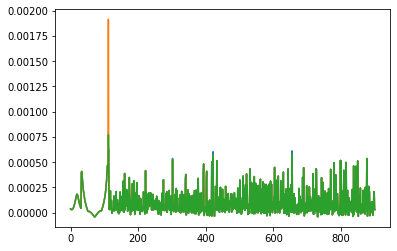

In [194]:
plt.plot((_M0).ravel())
plt.plot((_M1).ravel())
plt.plot((_M2).ravel())

(array([0.00061015]), array([0.00191404]), array([0.00076939]))

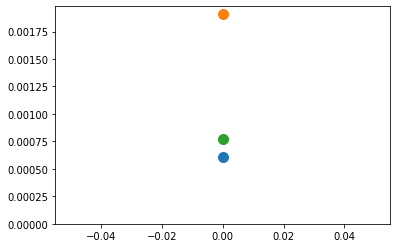

In [201]:
plt.plot(_M0[n_bdry_node], '.', markersize=20)
plt.plot(_M1[n_bdry_node], '.', markersize=20)
plt.plot(_M2[n_bdry_node], '.', markersize=20)
plt.ylim(bottom=0)
_M0[n_bdry_node], _M1[n_bdry_node], _M2[n_bdry_node]


In [ ]:
def int_r_G(R):
  ''' r * G partially integrated in r from 0 to r = R '''
  return (-1 / (2.0 * np.pi)) * R * R * (2 * np.log(R) - 1.0) / 4.0


def integrateG_ws(x_vertices, N_per_side=4, debug=False, method=2):
  ''' Integrates G in triangle including weak singularity.
  Polar coordinate integration dr dtheta. Analytic integration in
  dr direction, numerical integration in theta(r).
  
  Due to curvature approximation of the dtheta element, max expected order is 2.
  '''
  theta_tot = 0
  I = 0
  # Compute vertex coordinates relative to centroid
  x_shift = x_vertices - x_vertices.mean(axis=0)
  for _ii in range(3):
    # Compute vector representing edge of triangle
    _dx = x_shift[_ii] - x_shift[_ii-1]
    for _jj in range(N_per_side):
      # Trap integration along this edge
      interval_start  = x_shift[_ii-1] + (_jj) * _dx / N_per_side
      interval_center = x_shift[_ii-1] + (_jj + 0.5) * _dx / N_per_side
      interval_end    = x_shift[_ii-1] + (_jj + 1) * _dx / N_per_side
      r_start  = np.linalg.norm(interval_start)
      r_center = np.linalg.norm(interval_center)
      r_end    = np.linalg.norm(interval_end)
      theta_start = np.arctan2(interval_start[1], interval_start[0])
      theta_end   = np.arctan2(interval_end[1], interval_end[0])
      dtheta = np.mod(theta_end - theta_start, 2*np.pi)
      if method==3:
        dI = (int_r_G(r_start) + 4 * int_r_G(r_center) + int_r_G(r_end)) * dtheta / 6.0
      elif method==2:
        dI = (0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end)) * dtheta
      else:
        raise ValueError("Input param `method` options: {2, 3}.")
      I += dI
      if debug:
        print(dtheta, dI)
        theta_tot += dtheta
        plt.plot(interval_center[0], interval_center[1], '.')

  if debug:
    plt.plot(0, 0, 'ko')
    print(f"Total angle: {theta_tot/np.pi} * pi")
  return I

In [172]:
N_per_side = 2**np.arange(0,10)
v2 = [integrateG_ws(x_vertices, N_per_side=N, method=2) for N in N_per_side]
v3 = [integrateG_ws(x_vertices, N_per_side=N, method=3) for N in N_per_side]

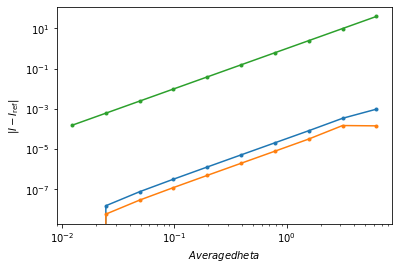

In [174]:
plt.loglog(2*np.pi / N_per_side, np.abs(v2 - v2[-1]), '.-')
plt.loglog(2*np.pi / N_per_side, np.abs(v3 - v3[-1]), '.-')
plt.xlabel("$Average d\theta$")
plt.ylabel("$|I - I_\mathrm{ref}|$")
plt.loglog(2*np.pi / N_per_side, (2*np.pi / N_per_side)**2, '.-')


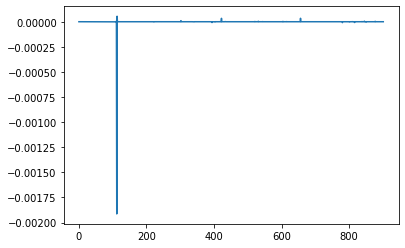

In [99]:
# plt.plot(_M0.ravel())
plt.plot((_M0-_M1).ravel())

C:\Users\Fredric\AppData\Local\Temp\ipykernel_38128\2848245941.py:3: RuntimeWarning: divide by zero encountered in log
  return -1 / (4.0 * np.pi) * np.log(np.einsum("...i, ...i -> ...", r, r))


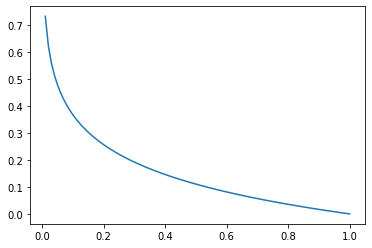

In [359]:
r_near = np.linspace(0,1,100)
G_near = G(np.stack([r_near, 0.0*r_near],axis=-1))
plt.plot(r_near, G_near)

# Theory

#### Theta-weighted timestepping
First, the integral representation theorem for nodes in the domain:

$$
\beta_\mathrm{d} \theta u^k + \beta_\mathrm{d}(1 - \theta) u^{k-1} = \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  - \frac{\partial K}{\partial n} u
  \right) d\gamma
  - \int_\Omega \left(
    \frac{u^{k} - u^{k-1}}{\Delta t}
    \right)
    K d\omega
$$

Rearranging dependent variables on the left and ``sources" on the right

$$
\beta_\mathrm{d} \theta u^k
+ \frac{1}{\Delta t} \int_\Omega u^{k} K d\omega 
- \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  \right) d\gamma
=
-\int_\Gamma \left(
\frac{\partial K}{\partial n} u
\right) d\gamma
+ \beta_\mathrm{d} (\theta - 1) u^{k-1}
+  \frac{1}{\Delta t} \int_\Omega u^{k-1} K d\omega
$$



or in term-by-term matrix form,

$$
\left(\beta_\mathrm{d} \theta I
+ \frac{1}{\Delta t}
M_\mathrm{dd} \right) u^{k}
-
K_{\mathrm{db}}
(\partial u / \partial n)_\Gamma^{k}
=
-C_\mathrm{db} u_\Gamma
+ \left(\beta_\mathrm{d} (\theta - 1) I
+ \frac{1}{\Delta t}
M_\mathrm{dd} \right) u^{k-1}
$$

Similarly, for the boundary points

$$
\frac{1}{\Delta t} \int_\Omega u^{k} K d\omega 
- \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  \right) d\gamma

\\ =
- \beta_\mathrm{b} \theta u_\Gamma^{k}
- \int_\Gamma \left(
\frac{\partial K}{\partial n} u
\right) d\gamma
+ \beta_\mathrm{b} (\theta - 1) u_\Gamma^{k-1}
+ \frac{1}{\Delta t} \int_\Omega u^{k-1} K d\omega
$$
where $u_\Gamma^{k}$ can be time-dependent. Consider for now $u_\Gamma$ being constant data. Then the matrix form is

$$
\frac{1}{\Delta t}
M_\mathrm{bd} u^{k}
-
K_{\mathrm{bb}}
(\partial u / \partial n)_\Gamma^{k}
=
\left( - C_\mathrm{bb} - \beta_\mathrm{b} I \right) u_\Gamma
+ \frac{1}{\Delta t}
M_\mathrm{bd} u^{k-1}
$$


Compactly,

$$
\begin{bmatrix}
-K_\mathrm{bb} & M_\mathrm{bd} / \Delta t \\
-K_\mathrm{db} & \beta_\mathrm{d} \theta I + M_\mathrm{dd} / \Delta t \\
\end{bmatrix}
\begin{bmatrix}
(\partial u/\partial n)_\Gamma^k \\
u^k \\
\end{bmatrix}
=
\begin{bmatrix}
-C_\mathrm{bb} - \beta_\mathrm{b} I \\
-C_\mathrm{db} \\
\end{bmatrix}
u_\Gamma
+
\begin{bmatrix}
M_\mathrm{bd} / \Delta t \\
\beta_\mathrm{d} (\theta - 1) I + M_\mathrm{dd} / \Delta t \\
\end{bmatrix} u^{k-1}
$$


Compact matrix equation (old, hidden)
<!-- \begin{bmatrix}
-K_\mathrm{bb} & M_\mathrm{bd} / \Delta t \\
-K_\mathrm{db} & \theta I - M_\mathrm{dd} / \Delta t \\
\end{bmatrix}
=
C u_\Gamma
+ (\theta - 1) u^{k-1}
- \frac{1}{\Delta t} 
\begin{bmatrix}
0 & M_\mathrm{bd} \\
& M_\mathrm{dd} \\
\end{bmatrix} u^{k-1} -->


## Code

Text(0.5, 1.0, 'Residual mapping from $u^{k-1}$')

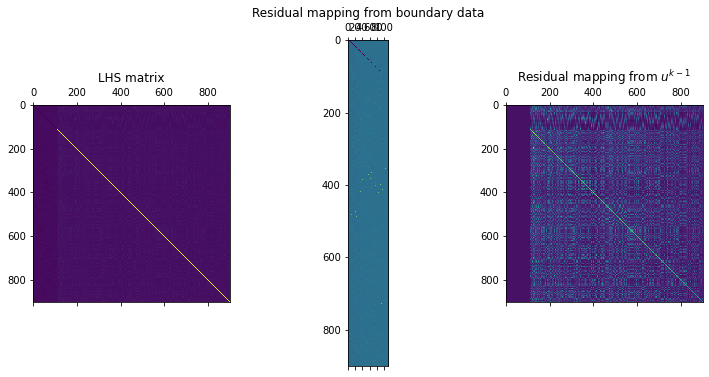

In [308]:
''' Matrix build '''

# Numerical method parameters
dt = 1e-2
theta = 1.0
# Geometric coefficient from deriving the boundary representation
beta_d = 1.0
beta_b = 0.5

L = np.concatenate((-K, M/dt), axis=1)
L[n_bdry_node:,n_bdry_node:] += beta_d * theta * np.eye(n_cells)

# Full-sized operators
C_op = -C.copy()
C_op[:n_bdry_node,:] -= beta_b * np.eye(n_bdry_node)
D_op = (M/dt).copy()
D_op[n_bdry_node:,:] += beta_d * (theta - 1.0) * np.eye(n_cells)
D_op = np.concatenate((np.zeros((N, n_bdry_node)), D_op), axis=1)

fig, ax = plt.subplots(1, 3, figsize=(12,6))
ax[0].matshow(L)
ax[0].set_title("LHS matrix")
ax[1].matshow(C_op)
ax[1].set_title("Residual mapping from boundary data")
ax[2].matshow(D_op)
ax[2].set_title("Residual mapping from $u^{k-1}$")


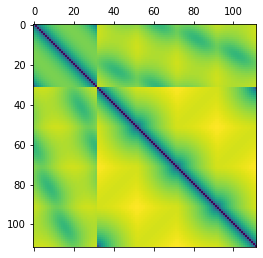

In [309]:
plt.matshow(L[0:n_bdry_node, 0:n_bdry_node])

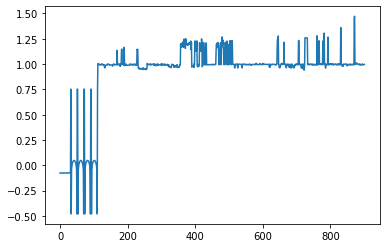

In [310]:
''' Timestepping '''

# Set constant Dirichlet data
u_bdry = np.ones((n_bdry_node,1))
# Set initial condition
u0 = np.zeros((N, 1))
u = u0.copy()

# Timestepping
N_t = 30

v_hist = np.zeros((N_t, n_circ_elts,))


for i in range(N_t):
  # Solve equation
  #   L @ q^{k} == CG @ u_Gamma + DG @ q^{k-1}
  u = np.linalg.solve(L, C_op @ u_bdry + D_op @ u)
  v_hist[i,:] = u[:n_circ_elts].ravel()
plt.plot(u)

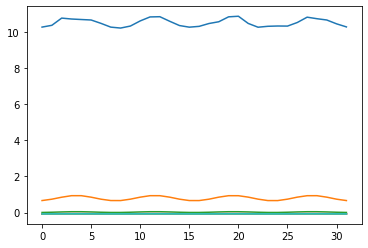

In [311]:
for i in range(0,N_t, N_t//10):
  plt.plot(v_hist[i,:])

In [312]:
# IDs of nodes that lie on the circular boundary
node_id_circ = np.unique(circ_edges_flat.ravel())
node_id_box = np.unique(box_edges_flat.ravel())

# Compute boolean array showing which cell ID is on the boundaries
is_cell_on_bdry_circ = np.empty((tri_nodes_flat.shape[0]), dtype=bool)
is_cell_on_bdry_box = np.empty((tri_nodes_flat.shape[0]), dtype=bool)
for i in range(tri_nodes_flat.shape[0]):
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_nodes_flat[i,:], node_id_circ)) == 0:
    is_cell_on_bdry_circ[i] = False
  else:
    is_cell_on_bdry_circ[i] = True
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_nodes_flat[i,:], node_id_box)) == 0:
    is_cell_on_bdry_box[i] = False
  else:
    is_cell_on_bdry_box[i] = True



1.471901481842862

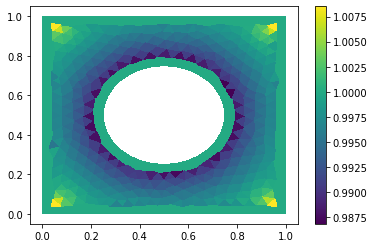

In [313]:
import matplotlib

# Extract du/dn, u_interior (u_Omega)
v = u[:n_bdry_node]
u_int = u[n_bdry_node:]

u_show = u_int.copy()
u_show[np.where(is_cell_on_bdry_circ)] = 1.0
u_show[np.where(is_cell_on_bdry_box)] = 1.0

triangulation = matplotlib.tri.Triangulation(mesh.points[:,0], mesh.points[:,1], tri_nodes_flat)
plt.tripcolor(triangulation, u_show.squeeze())
plt.colorbar()
u_int.max()

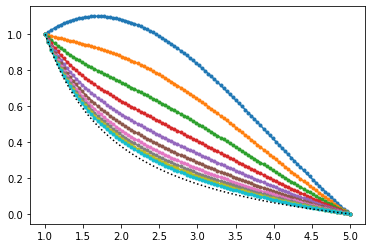

In [328]:
# Series solution for spherical shell heat conduction

def steady_term(r, t, a, b):
  return a / (a - b) * (1 - b / r)

def series_term(r, t, a, b, n):
  # Array of eigenvalues
  eig = n * np.pi / (b - a)
  # Return eigenfunction term with nondimensionalizing scaling (b - a) / 2
  return (b - a) / 2 * np.exp(-eig*eig * t) * np.sin(eig*(r - a)) / r

a = 1
b = 5
t_final = 5.0
for t in np.linspace(0, t_final, 10):
  r_test_range = np.linspace(a, b, 100)
  T_test = steady_term(r_test_range, t, a, b) + series_term(r_test_range, t, a, b, 1)
  plt.plot(r_test_range, T_test, '.-')

plt.plot(r_test_range, steady_term(r_test_range, t, a, b), 'k:')
